In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)


import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra.experimental import initialize, compose
from geofm_src.factory import create_dataset


# Set the config directory for OmegaConf to resolve relative paths
config_dir = 'geofm_src/configs/dataset'
# Note: if you run this multiple times, you need to clear the previous initialization
GlobalHydra.instance().clear()

# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/dataset")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:43: UserWarning: hydra.experimental.initialize() is no longer experimental. Use hydra.initialize()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  self.delegate = real_initialize(


hydra.experimental.initialize()

## Create splits 

If using for the first time: will save the splits to the root/splits directory

In [10]:
from geofm_src.datasets.fmow_wrapper import FmowBenchmarkDataset

dataset = FmowBenchmarkDataset(root='/data/panopticon/datasets/', split='test', )
dataset.df.head()

INFO:root:output_dtype: float32
INFO:root:Dataset size: 53473, sensor counts: {'WORLDVIEW02': 30148, 'WORLDVIEW03_VNIR': 10418, 'GEOEYE01': 9517, 'QUICKBIRD02': 3390, 'fmow_rgb': 0}
INFO:root:Normalizing images


,id,ms_path,ms_img_width,ms_img_height,ms_sensor_platform_name,ms_gsd,ms_timestamp,ms_approximate_wavelengths,ms_raw_location,rgb_path,rgb_img_width,rgb_img_height,rgb_sensor_platform_name,rgb_gsd,rgb_timestamp,rgb_approximate_wavelengths,rgb_raw_location,rgb_is_corrupt
0,shipyard_9_4,fmow/test/0010050/0010050_4_ms.tif,2629,1523,WORLDVIEW02,1.898325,2013-03-01T10:23:54Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_4_rgb.tif,10530,6099,WORLDVIEW02,0.473415,2013-03-01T10:23:54Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67947114370058...,True
1,shipyard_9_7,fmow/test/0010050/0010050_7_ms.tif,3569,2068,WORLDVIEW03_VNIR,1.403747,2016-01-05T10:11:07Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_7_rgb.tif,14289,8278,WORLDVIEW03_VNIR,0.350780,2016-01-05T10:11:07Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946551397688...,True
2,shipyard_9_0,fmow/test/0010050/0010050_0_ms.tif,2027,1175,QUICKBIRD02,2.483492,2003-09-07T09:32:10Z,"[474, 544, 661, 833]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_0_rgb.tif,8105,4695,QUICKBIRD02,0.621158,2003-09-07T09:32:10Z,"[661, 545, 477]","POLYGON ((20.412503388699999 54.6794661259515,...",True
3,shipyard_9_1,fmow/test/0010050/0010050_1_ms.tif,1211,702,QUICKBIRD02,4.192915,2014-01-24T09:35:10Z,"[474, 544, 661, 833]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_1_rgb.tif,4848,2808,QUICKBIRD02,1.051369,2014-01-24T09:35:10Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946929392450...,True
4,shipyard_9_6,fmow/test/0010050/0010050_6_ms.tif,3928,2276,WORLDVIEW03_VNIR,1.275527,2015-08-12T09:58:56Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_6_rgb.tif,15728,9111,WORLDVIEW03_VNIR,0.318811,2015-08-12T09:58:56Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946740734876...,True


In [23]:
import random

i = random.randint(0, len(dataset))
sample, label = dataset[i]
sample['imgs'].shape, label

(torch.Size([8, 1135, 1153]), 25)

# Test full dataset pipeline

## 8 band

In [2]:
# Compose your config - this will automatically handle all the defaults
ds_cfg = compose(config_name="fmow_8b")

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/compose.py:25: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'fmow_8b': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
INFO:root:output_dtype: float32


return_rgb: False


INFO:root:Removed 303 problematic images for train split with 8 channels


problematic_ids for 8 channels: ['shipyard_10_7', 'water_treatment_facility_1468_0', 'water_treatment_facility_208_2', 'water_treatment_facility_1315_0', 'airport_65_0', 'airport_345_0', 'park_170_0', 'park_461_1', 'park_276_0', 'park_635_3', 'park_610_1', 'park_619_0', 'park_699_1', 'park_645_0', 'park_710_0', 'park_390_0', 'solar_farm_284_1', 'solar_farm_309_0', 'solar_farm_850_3', 'solar_farm_1678_0', 'tower_349_3', 'parking_lot_or_garage_741_4', 'parking_lot_or_garage_2025_0', 'parking_lot_or_garage_775_3', 'parking_lot_or_garage_1744_0', 'parking_lot_or_garage_667_5', 'parking_lot_or_garage_277_0', 'parking_lot_or_garage_836_4', 'parking_lot_or_garage_985_4', 'parking_lot_or_garage_129_0', 'parking_lot_or_garage_117_2', 'parking_lot_or_garage_1176_0', 'parking_lot_or_garage_1840_0', 'parking_lot_or_garage_992_0', 'parking_lot_or_garage_891_0', 'parking_lot_or_garage_398_4', 'parking_lot_or_garage_1958_0', 'parking_lot_or_garage_1356_0', 'parking_lot_or_garage_1164_0', 'parking_lot

INFO:root:Dataset size: 275460, sensor counts: {'WORLDVIEW02': 204134, 'WORLDVIEW03_VNIR': 71326, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32
INFO:root:Removed 49 problematic images for val split with 8 channels
INFO:root:Dataset size: 40205, sensor counts: {'WORLDVIEW02': 30024, 'WORLDVIEW03_VNIR': 10181, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


problematic_ids for 8 channels: ['park_102_1', 'park_8_3', 'solar_farm_96_1', 'parking_lot_or_garage_139_1', 'parking_lot_or_garage_203_0', 'parking_lot_or_garage_43_2', 'parking_lot_or_garage_129_0', 'parking_lot_or_garage_160_0', 'parking_lot_or_garage_97_0', 'parking_lot_or_garage_191_0', 'parking_lot_or_garage_159_0', 'helipad_126_0', 'crop_field_395_0', 'crop_field_38_0', 'airport_terminal_124_1', 'interchange_65_0', 'police_station_111_0', 'recreational_facility_589_0', 'recreational_facility_271_0', 'recreational_facility_92_0', 'recreational_facility_384_0', 'recreational_facility_599_0', 'recreational_facility_231_3', 'recreational_facility_360_1', 'recreational_facility_466_4', 'recreational_facility_0_0', 'recreational_facility_116_0', 'recreational_facility_269_0', 'recreational_facility_614_0', 'railway_bridge_16_14', 'smokestack_11_0', 'educational_institution_100_0', 'educational_institution_207_0', 'educational_institution_221_0', 'stadium_0_19', 'stadium_0_18', 'milita

INFO:root:Removed 34 problematic images for test split with 8 channels
INFO:root:Dataset size: 40532, sensor counts: {'WORLDVIEW02': 30114, 'WORLDVIEW03_VNIR': 10418, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images


problematic_ids for 8 channels: ['water_treatment_facility_2_0', 'park_53_0', 'tower_179_0', 'parking_lot_or_garage_72_0', 'parking_lot_or_garage_14_3', 'parking_lot_or_garage_226_1', 'road_bridge_86_0', 'helipad_84_0', 'border_checkpoint_9_6', 'airport_terminal_75_0', 'ground_transportation_station_212_15', 'ground_transportation_station_21_1', 'interchange_67_0', 'recreational_facility_314_0', 'recreational_facility_325_2', 'recreational_facility_293_0', 'prison_54_4', 'educational_institution_189_1', 'educational_institution_39_1', 'educational_institution_248_0', 'place_of_worship_53_0', 'gas_station_156_0', 'electric_substation_157_1', 'waste_disposal_6_0', 'waste_disposal_129_0', 'waste_disposal_88_0', 'toll_booth_129_0', 'golf_course_8_0', 'golf_course_76_3', 'hospital_102_2', 'office_building_138_0', 'office_building_36_0', 'office_building_29_0', 'race_track_121_0']
{'dataset_type': 'fmow', 'task': 'classification', 'num_classes': 62, 'num_channels': 8, 'data_path': '${oc.env:

torch.Size([8, 224, 224]) 11 62
tensor(-0.9761) tensor(5.5126)


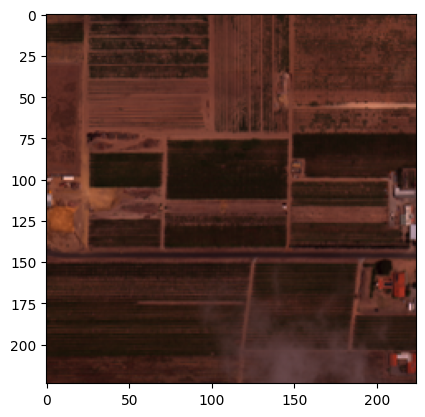

In [8]:
import random
import matplotlib.pyplot as plt
image, label = test_ds[random.randint(0, len(test_ds))]
print(image.shape, label, train_ds.num_classes)
print(image.min(), image.max())

image_rgb = image[[4,2,1], ...]
image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
image_rgb = image_rgb.permute(1, 2, 0)
plt.imshow(image_rgb)
plt.show()

# train_ds.plot(image)


In [9]:
sample, label = val_ds[1033]
sample, label = val_ds[1261]
print(sample.shape, label)


torch.Size([8, 224, 224]) 34


In [19]:
from tqdm.notebook import tqdm
import numpy as np
for i in tqdm(range(len(train_ds))):
    _, _ = train_ds[i]

# for i in tqdm(np.arange(171,175)):
#     _, _ = train_ds[i]

print(train_ds.problematic_ids)

  0%|          | 0/275762 [00:00<?, ?it/s]

KeyboardInterrupt: 

torch.Size([8, 224, 224]) 22 62


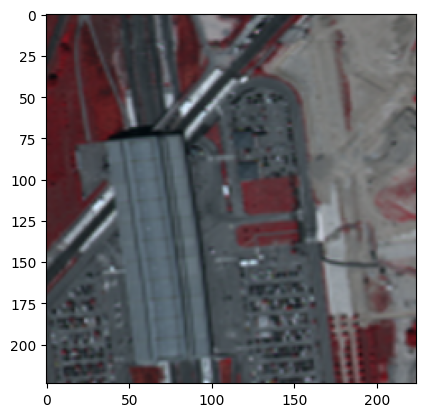

In [43]:
import random
import matplotlib.pyplot as plt
image, label = test_ds[random.randint(0, len(test_ds))]
print(image.shape, label, train_ds.num_classes)

image_rgb = image[[5,4,3], ...]
image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
image_rgb = image_rgb.permute(1, 2, 0)
plt.imshow(image_rgb)
plt.show()

# train_ds.plot(image)


## 4 Band

In [13]:
# Compose your config - this will automatically handle all the defaults
ds_cfg = compose(config_name="fmow_4b")
train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/compose.py:25: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'fmow_4b': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
INFO:root:output_dtype: float32


return_rgb: False


INFO:root:Dataset size: 87809, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 64606, 'QUICKBIRD02': 23203, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


problematic_ids for 4 channels: []


INFO:root:Dataset size: 12786, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 9448, 'QUICKBIRD02': 3338, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


problematic_ids for 4 channels: []


INFO:root:Dataset size: 12907, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 9517, 'QUICKBIRD02': 3390, 'fmow_rgb': 0}
INFO:root:Normalizing images


problematic_ids for 4 channels: []
{'dataset_type': 'fmow', 'task': 'classification', 'num_classes': 62, 'num_channels': 4, 'data_path': '${oc.env:DATASETS_DIR}', 'wavelengths_mean_nm': [665, 547, 482, 840], 'wavelengths_sigma_nm': [35, 58, 45, 83], 'wavelengths_mean_microns': [0.665, 0.547, 0.482, 0.84], 'multilabel': False, 'image_resolution': 224, 'subset': {'train': -1, 'val': -1, 'test': -1}, 'input_key': None, 'sequence_length': None, 'dataset_name': 'fmow_qbge', 'keep_sensors': ['QUICKBIRD02', 'GEOEYE01'], 'senpamae_channels': [0, 1, 2, 6], 'senpamae_srf_name': 'rfs_sentinel2_a.npy'}


torch.Size([4, 224, 224]) 36 62
tensor(-1.3976) tensor(7.2863)


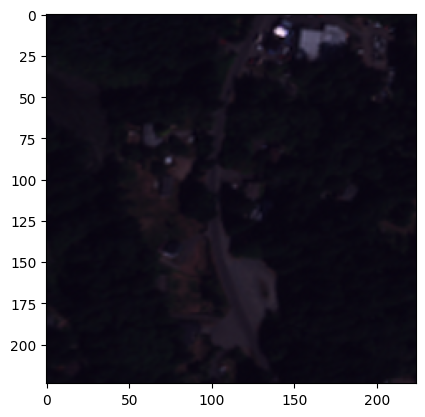

In [16]:
import random
import matplotlib.pyplot as plt
image, label = test_ds[random.randint(0, len(test_ds))]
print(image.shape, label, train_ds.num_classes)
print(image.min(), image.max())

image_rgb = image[[2,1,0], ...]
image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
image_rgb = image_rgb.permute(1, 2, 0)
plt.imshow(image_rgb)
plt.show()

# train_ds.plot(image)


# RGB

In [17]:
# Compose your config - this will automatically handle all the defaults
ds_cfg = compose(config_name="fmow_rgb")
train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/compose.py:25: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'fmow_rgb': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
INFO:root:output_dtype: float32


return_rgb: True


INFO:root:RGB Mode


problematic_ids for 3 channels: []


INFO:root:Dataset size: 363572, sensor counts: {'WORLDVIEW02': 204432, 'WORLDVIEW03_VNIR': 71331, 'GEOEYE01': 64606, 'QUICKBIRD02': 23203, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32
INFO:root:RGB Mode
INFO:root:Dataset size: 53040, sensor counts: {'WORLDVIEW02': 30070, 'WORLDVIEW03_VNIR': 10184, 'GEOEYE01': 9448, 'QUICKBIRD02': 3338, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


problematic_ids for 3 channels: []


INFO:root:RGB Mode
INFO:root:Dataset size: 53473, sensor counts: {'WORLDVIEW02': 30148, 'WORLDVIEW03_VNIR': 10418, 'GEOEYE01': 9517, 'QUICKBIRD02': 3390, 'fmow_rgb': 0}
INFO:root:Normalizing images


problematic_ids for 3 channels: []
{'dataset_type': 'fmow', 'task': 'classification', 'num_classes': 62, 'num_channels': 3, 'data_path': '${oc.env:DATASETS_DIR}', 'wavelengths_mean_nm': [665, 547, 482], 'wavelengths_sigma_nm': [35, 58, 45], 'wavelengths_mean_microns': [0.665, 0.547, 0.482], 'multilabel': False, 'image_resolution': 224, 'subset': {'train': -1, 'val': -1, 'test': -1}, 'input_key': None, 'sequence_length': None, 'dataset_name': 'fmow_rgb', 'keep_sensors': ['WORLDVIEW02', 'WORLDVIEW03_VNIR', 'QUICKBIRD02', 'GEOEYE01'], 'return_rgb': True}


torch.Size([3, 224, 224]) 48
tensor(-1.5870) tensor(2.2419)


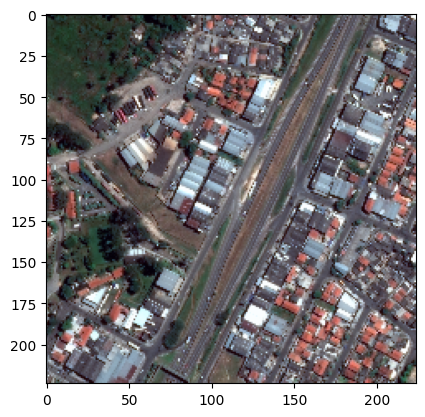

In [23]:
import random
import matplotlib.pyplot as plt
sample, label = test_ds[random.randint(0, len(test_ds))]
print(sample.shape, label)
print(sample.min(), sample.max())
img = sample.numpy().transpose(1, 2, 0)

img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.show()



